In [17]:
from sklearn.metrics.pairwise import euclidean_distances, cosine_distances
import matplotlib.pyplot as plt
from dynamicviz import boot
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np
import os
from scipy.io import mmread

Record time

In [2]:
datetime = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

### Define vars and functions

In [19]:

# path
path_work_dir = Path("/home/b05b01002/HDD/project_scRNAed")
path_input = path_work_dir / f"outputs/notebooks/Seurat-integrate-Ptr-samples/"
path_output = path_work_dir / f"outputs/notebooks/Seurat-integrate-Ptr-samples/{datetime}"
path_embeddings = path_input / "integrated.cca_ref=1_LogNorm_scaleFactor=10000.csv"
path_seurat_data = path_input / "integrated_data.cca_ref=1_LogNorm_scaleFactor=10000.mtx"
path_cell_ident = path_work_dir / "references/ptr_tenx_batch1_rs17_curated.csv"
path_cell_ident_all = path_output / "cell_identity_all.csv"
path_log = path_output / "log.txt"
os.makedirs(path_output, exist_ok=True)

# vars
distance_function = cosine_distances
color_palette = {
    1: "#1F77B4",
    2: "#7A4A33",
    3: "#E28413",
    4: "#F3EC5B",
    5: "#61C9A8",
    6: "#6362A7",
    7: "#FF0000",
    8: "#FF8F8F",
    9: "#D4D4D4",
    10: "#D4D4D4",
    11: "#D4D4D4",
    12: "#B03060"
}
batch_name = {
    "1": "ptr_tenx_batch1",
    "2": "ptr_tenx_batch2",
    "3": "ptr_tenx_tsv1",
    "4": "ptr_tenx_tsv2",
    "5": "ptr_tenx_tsv3",
    "6": "ptr_tenx_tsv4",
    "7": "ptr_tenx_tsv5",
    "8": "ptr_tenx_tst1",
    "9": "ptr_tenx_tst2",
    "10": "ptr_tenx_tst3",
    "11": "ptr_tenx_tst4",
    "12": "ptr_tenx_tso1",
    "13": "ptr_tenx_tso2",
    "14": "ptr_tenx_tso3",
    "15": "ptr_tenx_tso4"
}

# NN-annotation params
SIMILARITY_THRESHOLD = 0.7
DISTANCE_THRESHOLD = 1 - SIMILARITY_THRESHOLD

# DynamicViz params
B = 10

# UMAP params
n_neighbors = 10
min_dist = 0.01
metric = "cosine"

# setup logger
with open(path_log, "w") as handle:
    for name in dir():
        if not name.startswith("__"):
            handle.write(f"{name}: {eval(name)}")


### Get cell identity by nearest reference

Read reference cell identity

In [4]:
reference_cell_ident = pd.read_csv(path_cell_ident, index_col=0)
reference_cell_ident.head()

,Cluster,Color
Barcode,,
AAACCTGAGCACCGCT-1,8,#E377C2
AAACCTGCAAGAGTCG-1,7,#D62728
AAACCTGCACATTCGA-1,3,#FF7F0F
AAACCTGGTAAATGAC-1,3,#FF7F0F
AAACCTGGTCATCGGC-1,1,#1F77B4


Read embeddings of all bioreps

In [5]:
embeddings = pd.read_csv(
    path_embeddings,
    index_col=0
)
embeddings.head()

,integratedcca_1,integratedcca_2,integratedcca_3,integratedcca_4,integratedcca_5,integratedcca_6,integratedcca_7,integratedcca_8,integratedcca_9,integratedcca_10,...,integratedcca_41,integratedcca_42,integratedcca_43,integratedcca_44,integratedcca_45,integratedcca_46,integratedcca_47,integratedcca_48,integratedcca_49,integratedcca_50
AAACCTGAGCACCGCT-1_1,1.456899,0.220588,-8.934080,2.593900,-2.438819,-2.869881,-0.017296,0.358274,0.333970,-0.840459,...,-3.607326,-3.593970,-1.149655,-2.464433,1.883453,2.128854,2.383111,-0.096309,-2.000612,-0.305758
AAACCTGCAAGAGTCG-1_1,-10.712104,-6.077064,-0.884686,-3.217338,0.018846,-1.111805,-3.684145,0.398629,1.090848,5.487516,...,-0.460272,1.316104,1.287368,2.516165,-0.888734,-1.741134,-1.544191,-1.416862,-2.270248,1.481075
AAACCTGCACATTCGA-1_1,14.066334,-0.058805,4.151869,-3.575429,3.570798,2.827461,0.726574,-0.740440,7.195912,0.319724,...,0.603050,1.940725,0.509740,1.818369,0.038034,-2.532162,1.733276,0.565963,2.060368,-2.941073
AAACCTGGTAAATGAC-1_1,9.838598,1.508342,9.157059,-4.737559,-0.378952,1.276182,-0.036819,-1.744318,8.251368,-0.116762,...,-0.576091,1.335817,2.486313,2.599371,2.348203,-2.490349,0.136498,-1.460626,2.280404,-2.340530
AAACCTGGTCATCGGC-1_1,-6.341590,3.970059,-1.428951,-2.808142,0.091123,-0.156264,0.056294,1.145916,1.859389,0.506295,...,-2.556869,-0.424892,-0.051455,0.525370,0.029965,0.652290,0.342317,0.970634,0.263648,0.626640


Calculate pairwise distances

In [6]:
distance = distance_function(embeddings, embeddings.loc[["%s_1" % (i) for i in  reference_cell_ident.index]])
distance = pd.DataFrame(
    distance,
    index=embeddings.index,
    columns=reference_cell_ident.index
)

In [7]:
nearest_reference = distance.idxmin(axis=1)
cell_identity = pd.DataFrame(
    dict(
        Barcode=nearest_reference.index,
        Cluster=reference_cell_ident.loc[nearest_reference, "Cluster"].values,
        NN=nearest_reference.values,
        Distance=distance.min(axis=1).values
    )
)


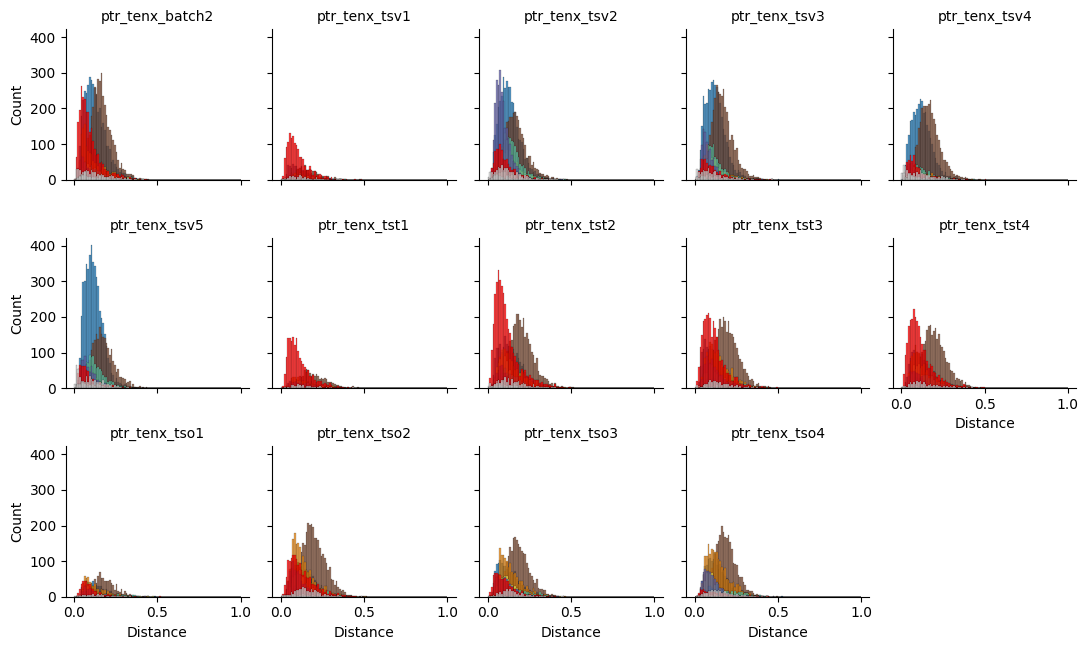

In [8]:
cell_identity["Batch"] = cell_identity.apply(lambda x: x.Barcode.split("_")[-1], axis=1).map(batch_name)
mask1 = cell_identity["Batch"] != "ptr_tenx_batch1"
grid = sns.FacetGrid(
    cell_identity[mask1],
    col="Batch",
    hue="Cluster",
    palette=color_palette,
    col_wrap=5,
    height=2.2
)
grid.map_dataframe(
    sns.histplot,
    x="Distance",
    bins=100,
    stat="count",
    binrange=(0, 1)
)
grid.set_titles(col_template="{col_name}")
grid.savefig(path_output / "hist_distance_to_NN.svg")

In [9]:
cell_identity.loc[cell_identity["Distance"] > DISTANCE_THRESHOLD, "Cluster"] = 12
cell_identity.to_csv(
    path_cell_ident_all,
    index=False
)

### Run UMAP on integrated CCA projections

In [10]:
X = embeddings.to_numpy()
Y = cell_identity
out = boot.generate(
    X,
    method="umap",
    Y=Y,
    B=B,
    no_bootstrap=True,
    num_jobs=min(50, B),
    save=path_output / f"dynamicviz.csv",
    use_n_pcs=False,
    subsample=False,
    return_times=False,
    **{
        "n_neighbors": n_neighbors,
        "min_dist": min_dist,
        "metric": metric,
    }
)

100%|██████████| 10/10 [00:00<00:00, 19.26it/s]


In [ ]:
median_umap = out.groupby("Barcode").median()
median_umap["Batch"] = [batch_name[i.split("_")[-1]] for i in median_umap.index]
batch_to_order = {v: int(k) for k, v in batch_name.items()}
median_umap = median_umap.sort_values(by="Batch", key=lambda x: x.map(batch_to_order)
median_umap.to_csv(path_output / "median_umap.csv")

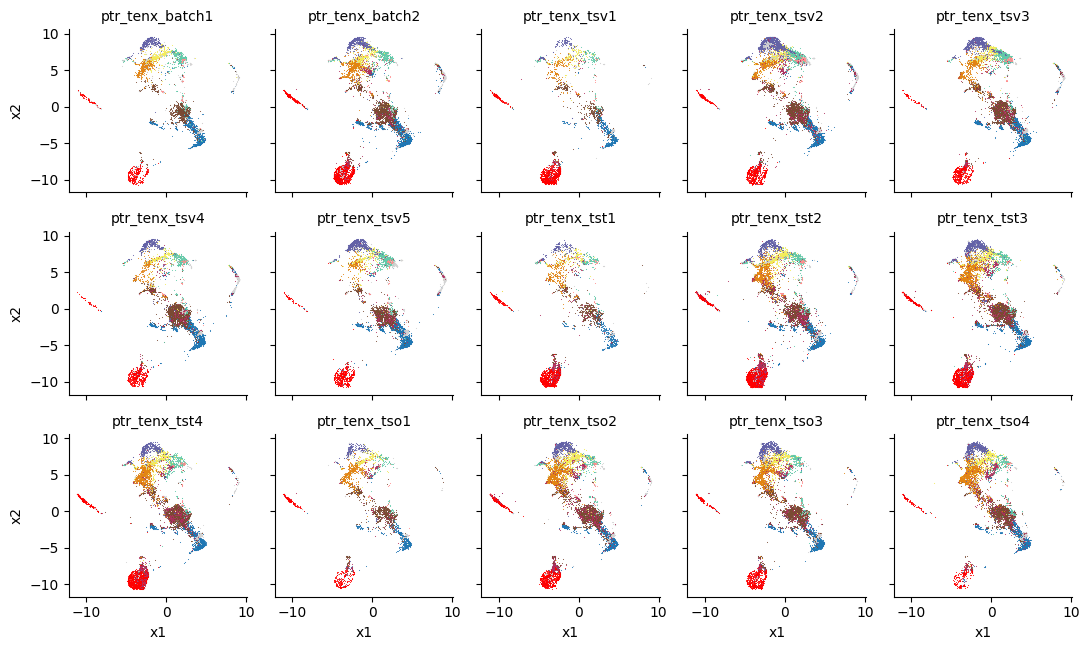

In [12]:
grid = sns.FacetGrid(
    median_umap,
    col="Batch",
    hue="Cluster",
    palette=color_palette,
    col_wrap=5,
    height=2.2
)
grid.map_dataframe(
    sns.scatterplot,
    x="x1",
    y="x2",
    s=0.5,
    edgecolors=None
)
grid.set_titles(col_template="{col_name}")
grid.savefig(path_output / f"median_umap.png")

In [13]:
print("Run above")
datetime

Run above


'20250729_172935'

# Unused

### Plot RNA editing level on UMAP

In [4]:
from scipy.io import mmread

sample_names = [
    "ptr_tenx_batch1",
    "ptr_tenx_batch2",
    "ptr_tenx_tsv1",
    "ptr_tenx_tsv2",
    "ptr_tenx_tsv3",
    "ptr_tenx_tsv4",
    "ptr_tenx_tsv5"
]
path_barcode = path_work_dir / "outputs/Remapping/renamer/{sample}/barcodes.tsv"
path_snv_loci = path_work_dir / "outputs/VariantCalling/vawk/{sample}.snv.loci.txt"
path_alt_mtx = path_work_dir / "outputs/VariantCalling/vartrix/{sample}/alt.mtx"
path_ref_mtx = path_work_dir / "outputs/VariantCalling/vartrix/{sample}/ref.mtx"
path_DRE_RO_vs_FuO = path_work_dir / "outputs/notebooks/Differential-analysis/DRES_RO_vs_FuO.csv"
path_DRE_RO_vs_Others = path_work_dir / "outputs/notebooks/Differential-analysis/DRES_RO_vs_Others.csv"
path_variant_annotation = path_work_dir / "outputs/notebooks/Check-proteome-alignment-results/variant_annotation_6frames.tsv"
path_annotation_info = path_work_dir / "references/Ptr/annotation/Ptrichocarpa_533_v4.1.annotation_info.txt"

# read data
DRE_RO_vs_FuO = pd.read_csv(path_DRE_RO_vs_FuO, sep=",")
DRE_RO_vs_Others = pd.read_csv(path_DRE_RO_vs_Others, sep=",")
variant_annotation = pd.read_csv(path_variant_annotation, sep="\t")
annotation_info = pd.read_csv(path_annotation_info, sep="\t")

# set index to dataframes
variant_annotation.index = variant_annotation.loc[:, ["CHROM", "POS"]].apply(lambda x: f"{x.CHROM}:{x.POS}", 1)
annotation_info.index = annotation_info["locusName"]

In [5]:
loci_of_interest = set(DRE_RO_vs_FuO["locus"].values) | set(DRE_RO_vs_Others["locus"].values)
loci_of_interest_annotated = set(variant_annotation.index) & loci_of_interest
loci_of_interest_annotated = list(loci_of_interest_annotated)

In [ ]:
gene_of_interest = variant_annotation.loc[loci_of_interest_annotated,"GENEID"].apply(lambda x: "%s.%s" % (x.split(".")[0], x.split(".")[1])).unique()
annotation_info_of_interest = annotation_info.loc[gene_of_interest]
annotation_info_of_interest.to_csv(
    path_output / "annotation_info_DRE_genes.csv",
    index=False
)

locusName
Potri.002G072100    AT1G77120
Potri.009G085100    AT1G50010
Potri.017G113300    AT5G16050
Potri.017G113300    AT5G16050
Potri.017G113300    AT5G16050
Potri.018G126400    AT5G20250
Potri.018G126400    AT5G20250
Potri.018G126400    AT5G20250
Potri.008G069400    AT3G55980
Potri.014G071200    AT2G45450
Potri.011G119700    AT4G27500
Potri.011G119700    AT4G27500
Potri.011G119700    AT4G27500
Potri.010G208300    AT5G54980
Potri.012G133950          NaN
Potri.012G113500    AT5G07440
Potri.005G219700    AT1G04270
Potri.007G099400          NaN
Potri.002G140100    AT3G10950
Potri.006G136700    AT5G20830
Potri.006G136700    AT5G20830
Potri.006G136700    AT5G20830
Potri.006G136700    AT5G20830
Potri.006G136700    AT5G20830
Potri.006G136700    AT5G20830
Potri.006G136700    AT5G20830
Potri.008G051200    AT2G28710
Potri.002G106800    AT1G09970
Potri.012G077300    AT5G50090
Potri.001G069100    AT3G61110
Potri.002G191400    AT2G47170
Potri.007G086000    AT5G65207
Potri.013G054200    AT3G04060


In [12]:
variant_annotation.loc[loci_of_interest_annotated].to_csv(
    path_output / "variant_annotation_DRE_genes.csv",
    index=False
)

In [98]:
variant_annotation["GENE_NAME"] = variant_annotation.apply(lambda x: "Potri.%s.v4.1" % (x.GENEID.split(".")[1]), 1)

In [99]:
loci_to_gene = variant_annotation.loc[loci_of_interest_annotated,:].apply(lambda x: f"{x.CHROM}-{x.POS}_{x.GENE_NAME}", 1)
loci_to_gene = {idx: value for idx, value in zip(loci_to_gene.index, loci_to_gene)}
loci_to_gene

{'Chr02:5058364': 'Chr02-5058364_Potri.002G072100.v4.1',
 'Chr09:7998571': 'Chr09-7998571_Potri.009G085100.v4.1',
 'Chr17:12070245': 'Chr17-12070245_Potri.017G113300.v4.1',
 'Chr18:13765592': 'Chr18-13765592_Potri.018G126400.v4.1',
 'Chr02:5058404': 'Chr02-5058404_Potri.002G072100.v4.1',
 'Chr08:4239255': 'Chr08-4239255_Potri.008G069400.v4.1',
 'Chr14:4538500': 'Chr14-4538500_Potri.014G071200.v4.1',
 'Chr11:15074200': 'Chr11-15074200_Potri.011G119700.v4.1',
 'Chr10:19818286': 'Chr10-19818286_Potri.010G208300.v4.1',
 'Chr12:14922345': 'Chr12-14922345_Potri.012G133950.v4.1',
 'Chr12:13302741': 'Chr12-13302741_Potri.012G113500.v4.1',
 'Chr05:22214891': 'Chr05-22214891_Potri.005G219700.v4.1',
 'Chr07:12410852': 'Chr07-12410852_Potri.007G099400.v4.1',
 'Chr02:10512592': 'Chr02-10512592_Potri.002G140100.v4.1',
 'Chr06:11264784': 'Chr06-11264784_Potri.006G136700.v4.1',
 'Chr08:3004928': 'Chr08-3004928_Potri.008G051200.v4.1',
 'Chr02:7891079': 'Chr02-7891079_Potri.002G106800.v4.1',
 'Chr12:100

In [104]:
alt_frac_all = None
for idx, i in enumerate(sample_names):
    loci = pd.read_csv(path_snv_loci.__str__().replace("{sample}", i), header=None)
    is_loci_of_interest = loci[0].isin(loci_of_interest)
    print("Found", sum(is_loci_of_interest), "loci in sample:", i)
    barcode = pd.read_csv(path_barcode.__str__().replace("{sample}", i), header=None)
    alt_mtx_temp = mmread(path_alt_mtx.__str__().replace("{sample}", i)).tocsr()
    ref_mtx_temp = mmread(path_ref_mtx.__str__().replace("{sample}", i)).tocsr()
    alt_mtx_temp = alt_mtx_temp[is_loci_of_interest, ]
    ref_mtx_temp = ref_mtx_temp[is_loci_of_interest, ]
    cov_mtx_temp = alt_mtx_temp + ref_mtx_temp
    alt_frac_temp = alt_mtx_temp / cov_mtx_temp
    alt_frac = pd.DataFrame(alt_frac_temp.T)
    alt_frac.columns = loci.loc[is_loci_of_interest, 0]
    alt_frac.index = [f"{i}_{idx+1}" for i in barcode[0]]
    alt_frac[pd.DataFrame.sparse.from_spmatrix(cov_mtx_temp) < 5] = 0
    alt_frac[alt_frac.isna()] = 0
    if alt_frac_all is None:
        alt_frac_all = alt_frac
    else:
        alt_frac_all = pd.concat([alt_frac_all, alt_frac], sort=False)

alt_frac_all[alt_frac_all.isna()] = 0

Found 33 loci in sample: ptr_tenx_batch1
Found 5 loci in sample: ptr_tenx_batch2
Found 11 loci in sample: ptr_tenx_tsv1
Found 6 loci in sample: ptr_tenx_tsv2
Found 3 loci in sample: ptr_tenx_tsv3
Found 2 loci in sample: ptr_tenx_tsv4
Found 3 loci in sample: ptr_tenx_tsv5


In [105]:
alt_frac_all = alt_frac_all.rename(
    loci_to_gene, axis = 1
)

In [106]:
alt_frac_all.to_csv(
    path_output / "editing_level.csv"
)